# Performance Estimation & Benchmark Results

Set `WORKLOAD` below to select which input/output configuration to view.

In [1]:
import json
import glob
import os
import pandas as pd

# ─── Select workload ───────────────────────────────────────────────
WORKLOAD = "in763-out232"  # Change this to view different workloads
# ───────────────────────────────────────────────────────────────────

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
EST_DIR = os.path.join(BASE_DIR, WORKLOAD, "results", "data", "estimated")
MEAS_DIR = os.path.join(BASE_DIR, WORKLOAD, "results", "data", "measured")

available = sorted([
    d for d in os.listdir(BASE_DIR)
    if d.startswith("in") and "-out" in d and os.path.isdir(os.path.join(BASE_DIR, d))
])
print(f"Available workloads: {available}")
print(f"Selected: {WORKLOAD}")

Available workloads: ['in763-out232']
Selected: in763-out232


## Helper Functions

In [2]:
COLS = ["ttft_ms", "tpot_ms", "e2e_ms", "rps"]


def load_estimated(est_dir: str = EST_DIR) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(est_dir, "est_*.json")))
    rows = []
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        if not d.get("feasible", False):
            continue
        for entry in d.get("batch_sweep", []):
            rows.append({
                "instance": d["instance_type"],
                "tp": d["tp_size"],
                "pp": d["pp_size"],
                "batch": entry["batch_size"],
                "ttft_ms": round(entry.get("ttft_ms", 0), 2),
                "tpot_ms": round(entry.get("tpot_ms", 0), 4),
                "e2e_ms": round(entry["batch_latency_ms"], 2),
                "rps": round(entry["throughput_rps"], 4),
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["instance", "tp", "pp", "batch"]).reset_index(drop=True)
    return df


def load_measured(meas_dir: str = MEAS_DIR) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(meas_dir, "bench_*.json")))
    rows = []
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        for entry in d.get("batch_sweep", []):
            rows.append({
                "instance": d["instance_type"],
                "tp": d["tp_size"],
                "pp": d["pp_size"],
                "batch": entry["batch_size"],
                "ttft_ms": round(entry["mean_ttft_ms"], 2),
                "tpot_ms": round(entry["mean_tpot_ms"], 4),
                "e2e_ms": round(entry["mean_e2el_ms"], 2),
                "rps": round(entry["request_throughput"], 4),
                "completed": entry["completed"],
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["instance", "tp", "pp", "batch"]).reset_index(drop=True)
    return df


JOIN_KEYS = ["instance", "tp", "pp", "batch"]


def merge_est_meas(est_df, meas_df) -> pd.DataFrame:
    merged = pd.merge(est_df, meas_df, on=JOIN_KEYS, suffixes=("_est", "_meas"))
    return merged.sort_values(JOIN_KEYS).reset_index(drop=True)


def compute_mape(merged_df) -> pd.DataFrame:
    """MAPE per (instance, tp, pp). Result in %."""
    def _mape(g):
        return pd.Series({
            f"{c}_mape%": ((g[f"{c}_est"] - g[f"{c}_meas"]).abs() / g[f"{c}_meas"].abs().clip(lower=1e-9) * 100).mean()
            for c in COLS
        })
    return merged_df.groupby(["instance", "tp", "pp"]).apply(_mape).round(2).reset_index()


def compute_overall_mape(merged_df) -> pd.Series:
    """Overall MAPE in %."""
    result = pd.Series({
        f"{c}_mape%": ((merged_df[f"{c}_est"] - merged_df[f"{c}_meas"]).abs() / merged_df[f"{c}_meas"].abs().clip(lower=1e-9) * 100).mean()
        for c in COLS
    })
    return result.round(2)


def filter_df(df, instance=None, tp=None, pp=None):
    if instance:
        df = df[df["instance"] == instance]
    if tp:
        df = df[df["tp"] == tp]
    if pp:
        df = df[df["pp"] == pp]
    return df.reset_index(drop=True)


def max_batch_summary(df):
    return (
        df.loc[df.groupby(["instance", "tp", "pp"])["batch"].idxmax()]
        .sort_values(["instance", "tp", "pp"])
        .reset_index(drop=True)
    )

---
## 1. Estimated

In [3]:
est_df = load_estimated()
print(f"Estimated: {len(est_df)} rows, {est_df.groupby(['instance','tp','pp']).ngroups} configs")
max_batch_summary(est_df)

Estimated: 164 rows, 18 configs


,instance,tp,pp,batch,ttft_ms,tpot_ms,e2e_ms,rps
0,g5.48xlarge,2,4,11,13602.17,14.5036,50615.34,0.2173
1,g5.48xlarge,4,2,30,67634.12,4.2458,97184.63,0.3087
2,g5.48xlarge,8,1,33,96919.82,4.7788,133506.65,0.2472
3,g6.48xlarge,2,4,11,8812.74,26.8391,77306.06,0.1423
4,g6.48xlarge,4,2,30,34711.06,5.5461,73312.26,0.4092
5,g6.48xlarge,8,1,33,44300.91,3.7073,72683.80,0.4540
6,g6e.48xlarge,1,8,443,61678.59,0.5503,118239.77,3.7466
7,g6e.48xlarge,2,4,481,229467.05,0.5361,289292.91,1.6627
8,g6e.48xlarge,4,2,499,442695.21,0.8428,540259.41,0.9236
9,g6e.48xlarge,8,1,502,584920.25,1.5747,768311.35,0.6534


---
## 2. Measured

In [4]:
meas_df = load_measured()
if meas_df.empty:
    print("No measured data yet.")
else:
    # Join with estimated to compute MAPE
    meas_with_mape = pd.merge(meas_df, est_df, on=JOIN_KEYS, suffixes=('', '_est'))
    for c in COLS:
        meas_with_mape[f"{c}_mape%"] = ((meas_with_mape[f"{c}_est"] - meas_with_mape[c]).abs() / meas_with_mape[c].abs().clip(lower=1e-9) * 100).round(2)
    drop_cols = [f"{c}_est" for c in COLS]
    meas_with_mape = meas_with_mape.drop(columns=drop_cols)
    print(f"Measured: {len(meas_df)} rows, {meas_df.groupby(['instance','tp','pp']).ngroups} configs")
    display(max_batch_summary(meas_with_mape))

Measured: 84 rows, 13 configs


,instance,tp,pp,batch,ttft_ms,tpot_ms,e2e_ms,rps,completed,ttft_ms_mape%,tpot_ms_mape%,e2e_ms_mape%,rps_mape%
0,g5.48xlarge,2,4,8,8577.83,452.8519,113186.61,0.1413,80,15.33,95.66,59.02,22.08
1,g5.48xlarge,4,2,16,20641.83,398.2837,112645.36,0.2838,160,74.75,98.40,46.92,5.71
2,g5.48xlarge,8,1,32,80080.03,1088.9161,331619.64,0.1916,320,17.36,99.56,60.88,28.76
3,g6.48xlarge,2,4,8,4757.32,671.1135,159784.54,0.1001,80,34.72,94.52,53.31,7.09
4,g6.48xlarge,4,2,16,8148.55,405.5404,101828.39,0.3139,160,127.19,97.62,46.60,6.28
5,g6.48xlarge,8,1,33,27614.75,575.3216,160514.04,0.3996,330,60.42,99.36,54.72,13.61
6,g6e.48xlarge,2,4,128,20732.83,615.7065,162961.04,1.5586,1280,194.53,99.82,41.91,13.24
7,g6e.48xlarge,4,2,128,32470.25,713.2620,197233.77,1.2897,1280,249.73,99.84,25.33,32.61
8,g6e.48xlarge,8,1,128,78684.03,1413.8172,405275.79,0.6295,1280,89.55,99.88,50.81,2.00
9,p4d.24xlarge,1,8,64,4339.89,356.1205,86603.72,1.4683,640,54.96,99.46,59.55,24.43


---
## 3. Estimated vs Measured

`*_ae` = |estimated − measured|

In [5]:
if not meas_df.empty:
    merged = merge_est_meas(est_df, meas_df)
    print(f"Matched: {len(merged)} rows")
    display(merged)
else:
    print("No measured data to compare.")

Matched: 84 rows


,instance,tp,pp,batch,ttft_ms_est,tpot_ms_est,e2e_ms_est,rps_est,ttft_ms_meas,tpot_ms_meas,e2e_ms_meas,rps_meas,completed
0,g5.48xlarge,2,4,1,2826.42,154.3356,38632.29,0.0259,2329.29,331.3329,78867.19,0.0254,10
1,g5.48xlarge,2,4,2,3533.03,77.1678,39338.89,0.0508,3857.69,345.8765,83755.15,0.0477,20
2,g5.48xlarge,2,4,4,4946.24,38.5839,40752.10,0.0982,3559.53,390.4137,93745.10,0.0853,40
3,g5.48xlarge,2,4,8,9892.49,19.6637,46388.24,0.1725,8577.83,452.8519,113186.61,0.1413,80
4,g5.48xlarge,4,2,1,3005.96,77.0841,20889.48,0.0479,3135.48,215.8638,53000.01,0.0377,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,p4d.24xlarge,8,1,16,1091.44,0.9030,4443.30,3.6009,1205.69,113.1036,27332.61,1.1632,160
80,p4d.24xlarge,8,1,32,2182.89,0.4788,5737.31,5.5775,1831.60,127.6058,31308.54,2.0215,320
81,p4d.24xlarge,8,1,64,4365.77,0.2667,8325.32,7.6874,2933.17,151.5157,37933.29,3.3129,640
82,p4d.24xlarge,8,1,128,8731.55,0.1606,13501.34,9.4805,5174.17,203.5504,52194.31,4.7760,1280


### 3a. MAPE per Config (%)

In [6]:
if not meas_df.empty:
    display(compute_mape(merged))

,instance,tp,pp,ttft_ms_mape%,tpot_ms_mape%,e2e_ms_mape%,rps_mape%
0,g5.48xlarge,2,4,21.01,79.22,54.90,11.42
1,g5.48xlarge,4,2,41.49,86.63,55.13,15.12
2,g5.48xlarge,8,1,9.71,90.23,59.46,23.96
3,g6.48xlarge,2,4,25.63,76.25,49.80,5.02
4,g6.48xlarge,4,2,86.60,82.03,50.02,3.18
5,g6.48xlarge,8,1,31.36,88.55,54.86,11.56
6,g6e.48xlarge,2,4,128.94,98.99,48.66,7.50
7,g6e.48xlarge,4,2,128.12,91.21,45.74,18.67
8,g6e.48xlarge,8,1,37.68,92.97,58.04,21.34
9,p4d.24xlarge,1,8,29.68,85.36,53.14,13.46


### 3b. Overall MAPE

In [7]:
if not meas_df.empty:
    overall = compute_overall_mape(merged)
    print("Overall MAPE:")
    for k, v in overall.items():
        print(f"  {k}: {v}%")

Overall MAPE:
  ttft_ms_mape%: 54.71%
  tpot_ms_mape%: 89.9%
  e2e_ms_mape%: 59.29%
  rps_mape%: 44.32%


### 3c. Config Summary (max batch)

In [8]:
if not meas_df.empty:
    summary = merged[["instance", "tp", "pp", "batch"]].copy()
    for c in COLS:
        summary[f"{c}_est"] = merged[f"{c}_est"].values
        summary[f"{c}_meas"] = merged[f"{c}_meas"].values
        meas_vals = merged[f"{c}_meas"].values
        summary[f"{c}_mape%"] = (abs(merged[f"{c}_est"].values - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100).round(2)
    display(summary)

,instance,tp,pp,batch,ttft_ms_est,ttft_ms_meas,ttft_ms_mape%,tpot_ms_est,tpot_ms_meas,tpot_ms_mape%,e2e_ms_est,e2e_ms_meas,e2e_ms_mape%,rps_est,rps_meas,rps_mape%
0,g5.48xlarge,2,4,1,2826.42,2329.29,21.34,154.3356,331.3329,53.42,38632.29,78867.19,51.02,0.0259,0.0254,1.97
1,g5.48xlarge,2,4,2,3533.03,3857.69,8.42,77.1678,345.8765,77.69,39338.89,83755.15,53.03,0.0508,0.0477,6.50
2,g5.48xlarge,2,4,4,4946.24,3559.53,38.96,38.5839,390.4137,90.12,40752.10,93745.10,56.53,0.0982,0.0853,15.12
3,g5.48xlarge,2,4,8,9892.49,8577.83,15.33,19.6637,452.8519,95.66,46388.24,113186.61,59.02,0.1725,0.1413,22.08
4,g5.48xlarge,4,2,1,3005.96,3135.48,4.13,77.0841,215.8638,64.29,20889.48,53000.01,60.59,0.0479,0.0377,27.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,p4d.24xlarge,8,1,16,1091.44,1205.69,9.48,0.9030,113.1036,99.20,4443.30,27332.61,83.74,3.6009,1.1632,209.57
80,p4d.24xlarge,8,1,32,2182.89,1831.60,19.18,0.4788,127.6058,99.62,5737.31,31308.54,81.67,5.5775,2.0215,175.91
81,p4d.24xlarge,8,1,64,4365.77,2933.17,48.84,0.2667,151.5157,99.82,8325.32,37933.29,78.05,7.6874,3.3129,132.04
82,p4d.24xlarge,8,1,128,8731.55,5174.17,68.75,0.1606,203.5504,99.92,13501.34,52194.31,74.13,9.4805,4.7760,98.50


---
## 5. Estimated vs Measured Bar Charts

Per instance × strategy, across all batch sizes.  
Left: raw values. Right: normalized to batch=1.

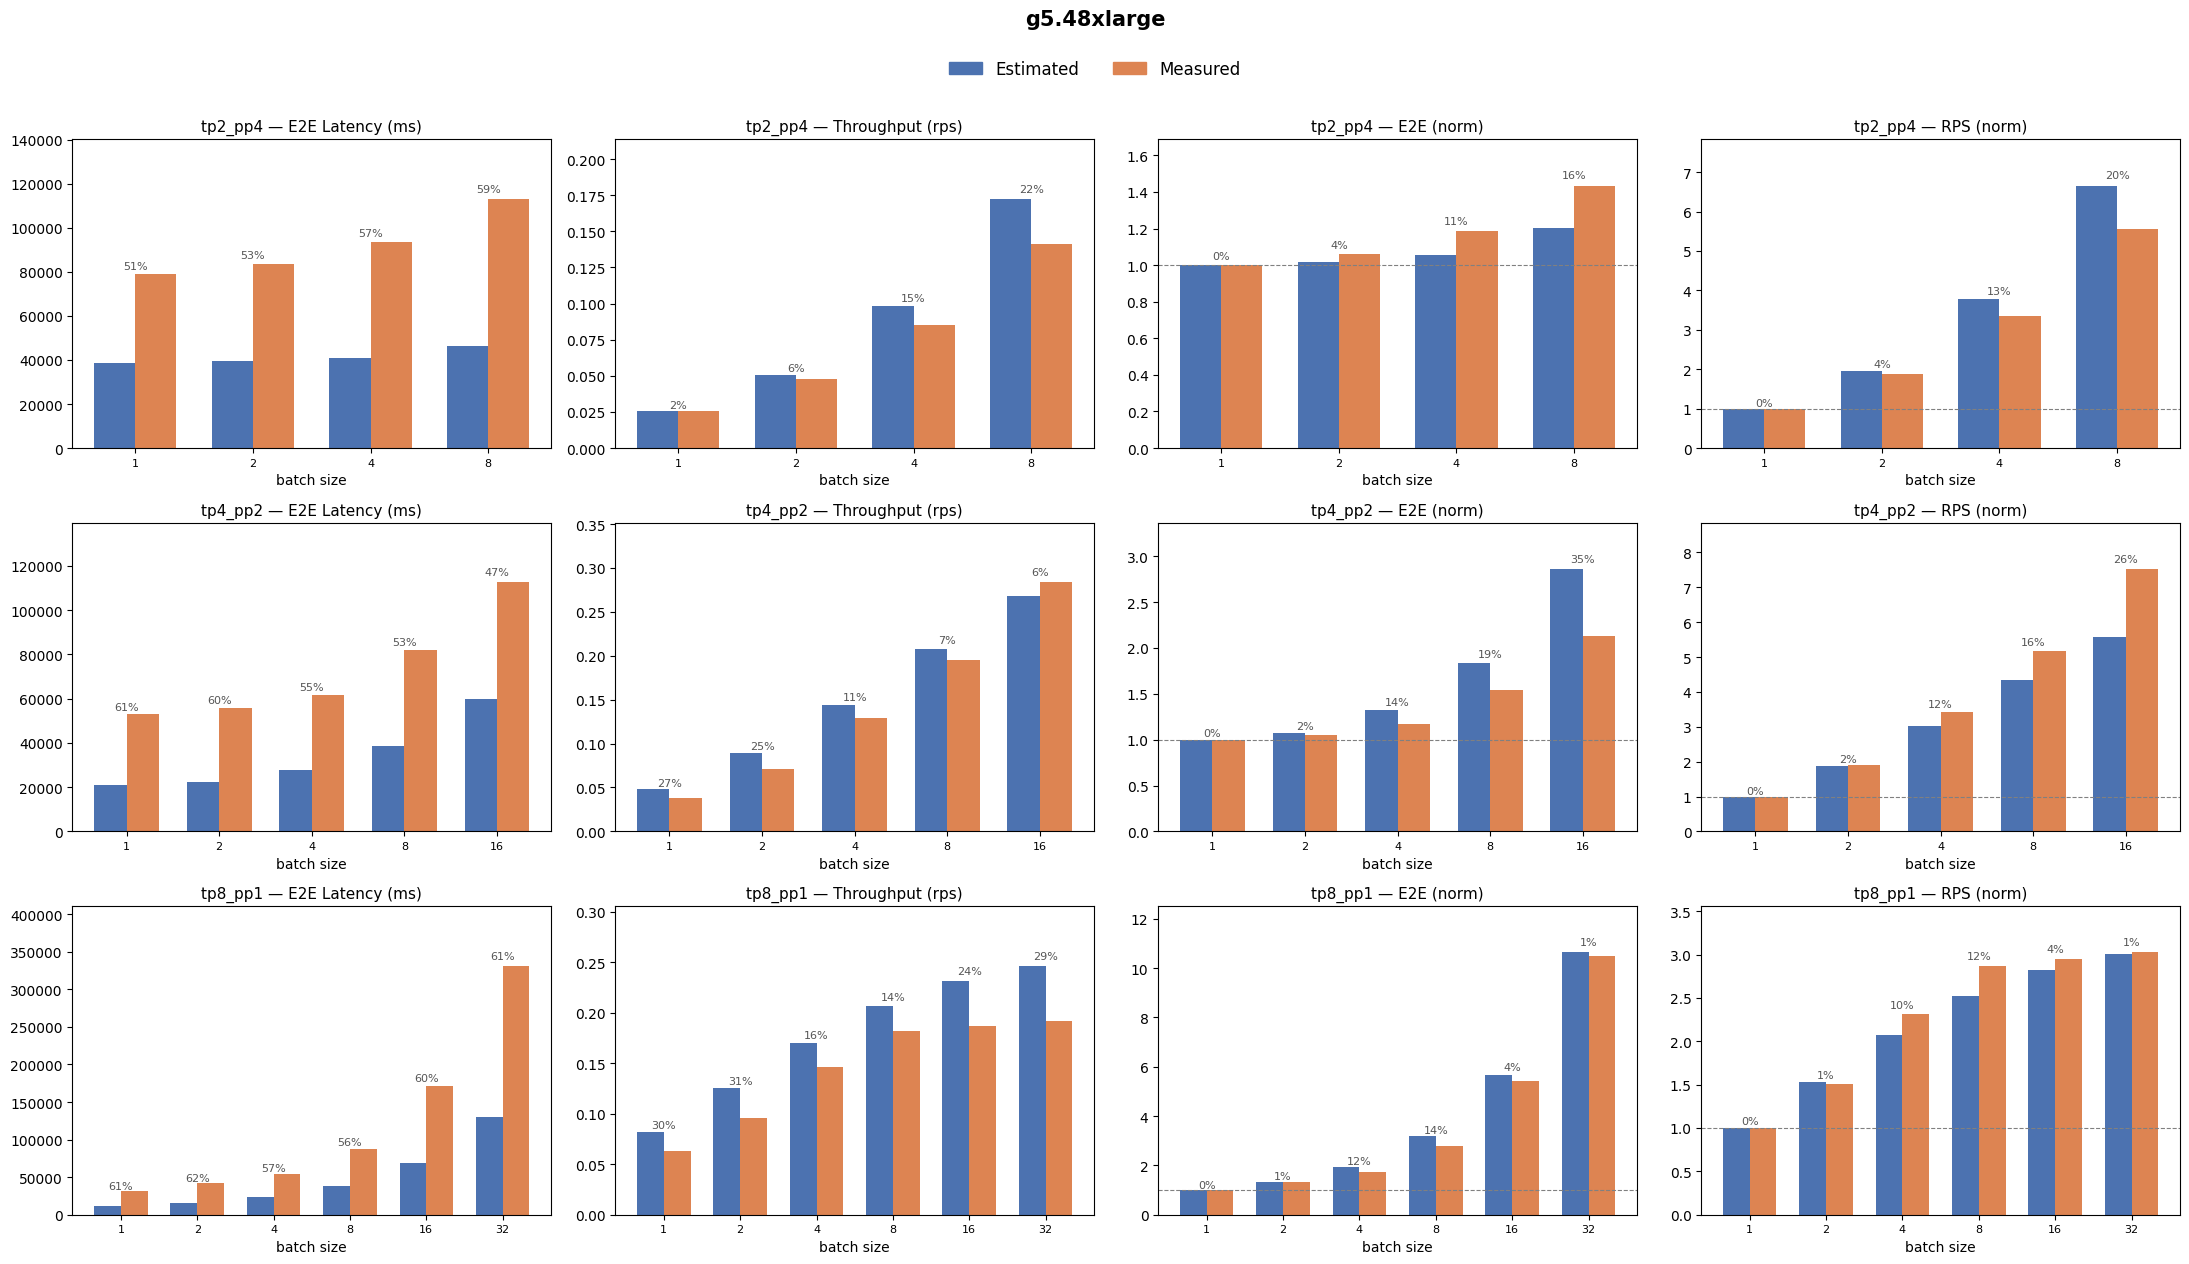

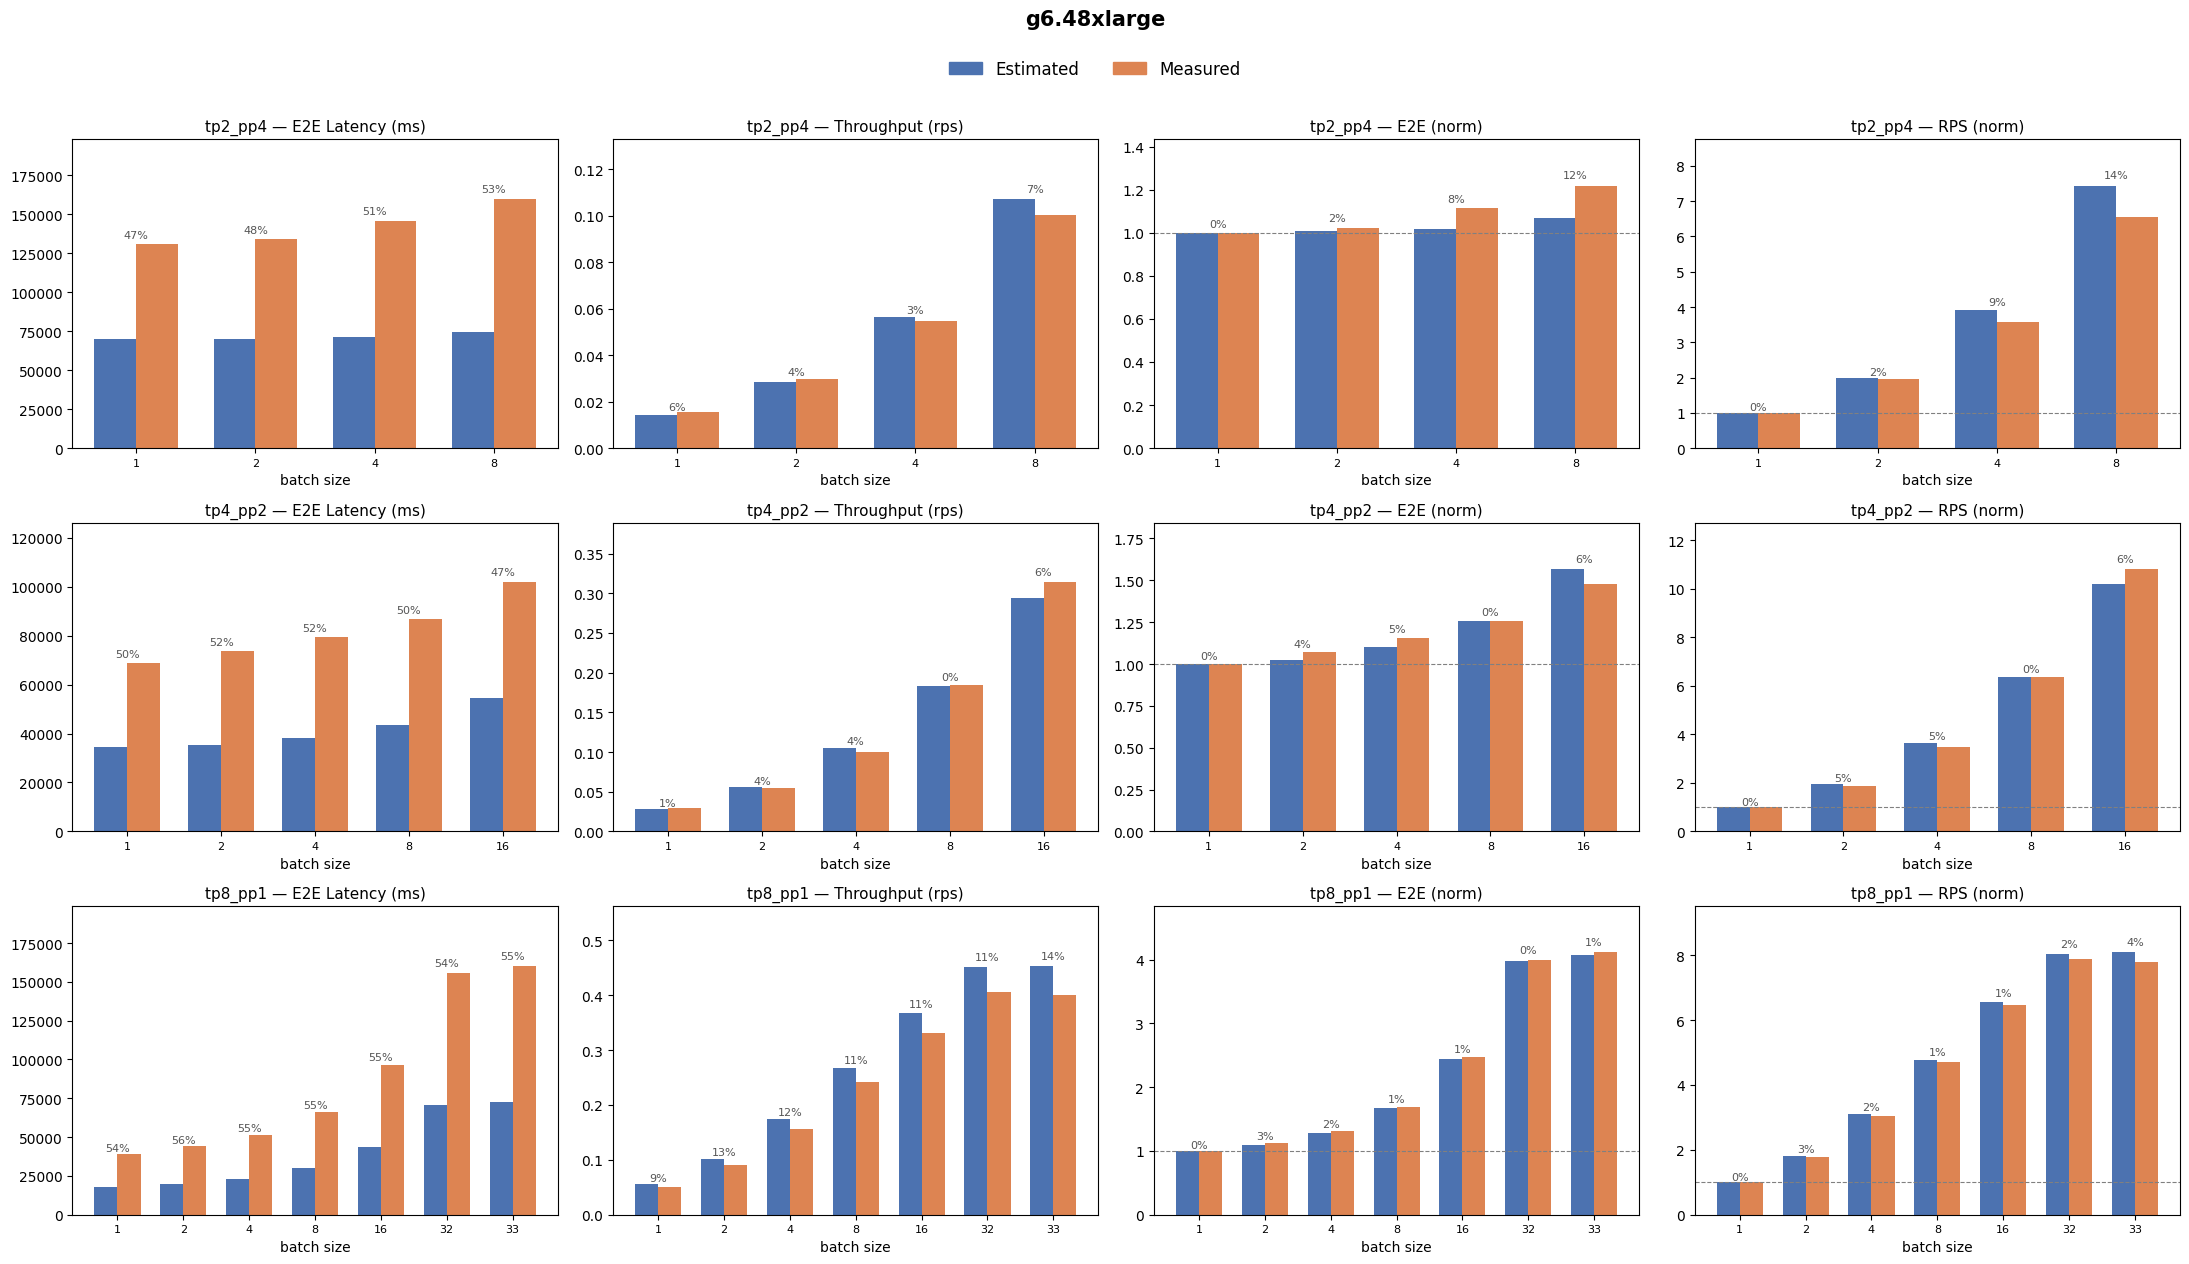

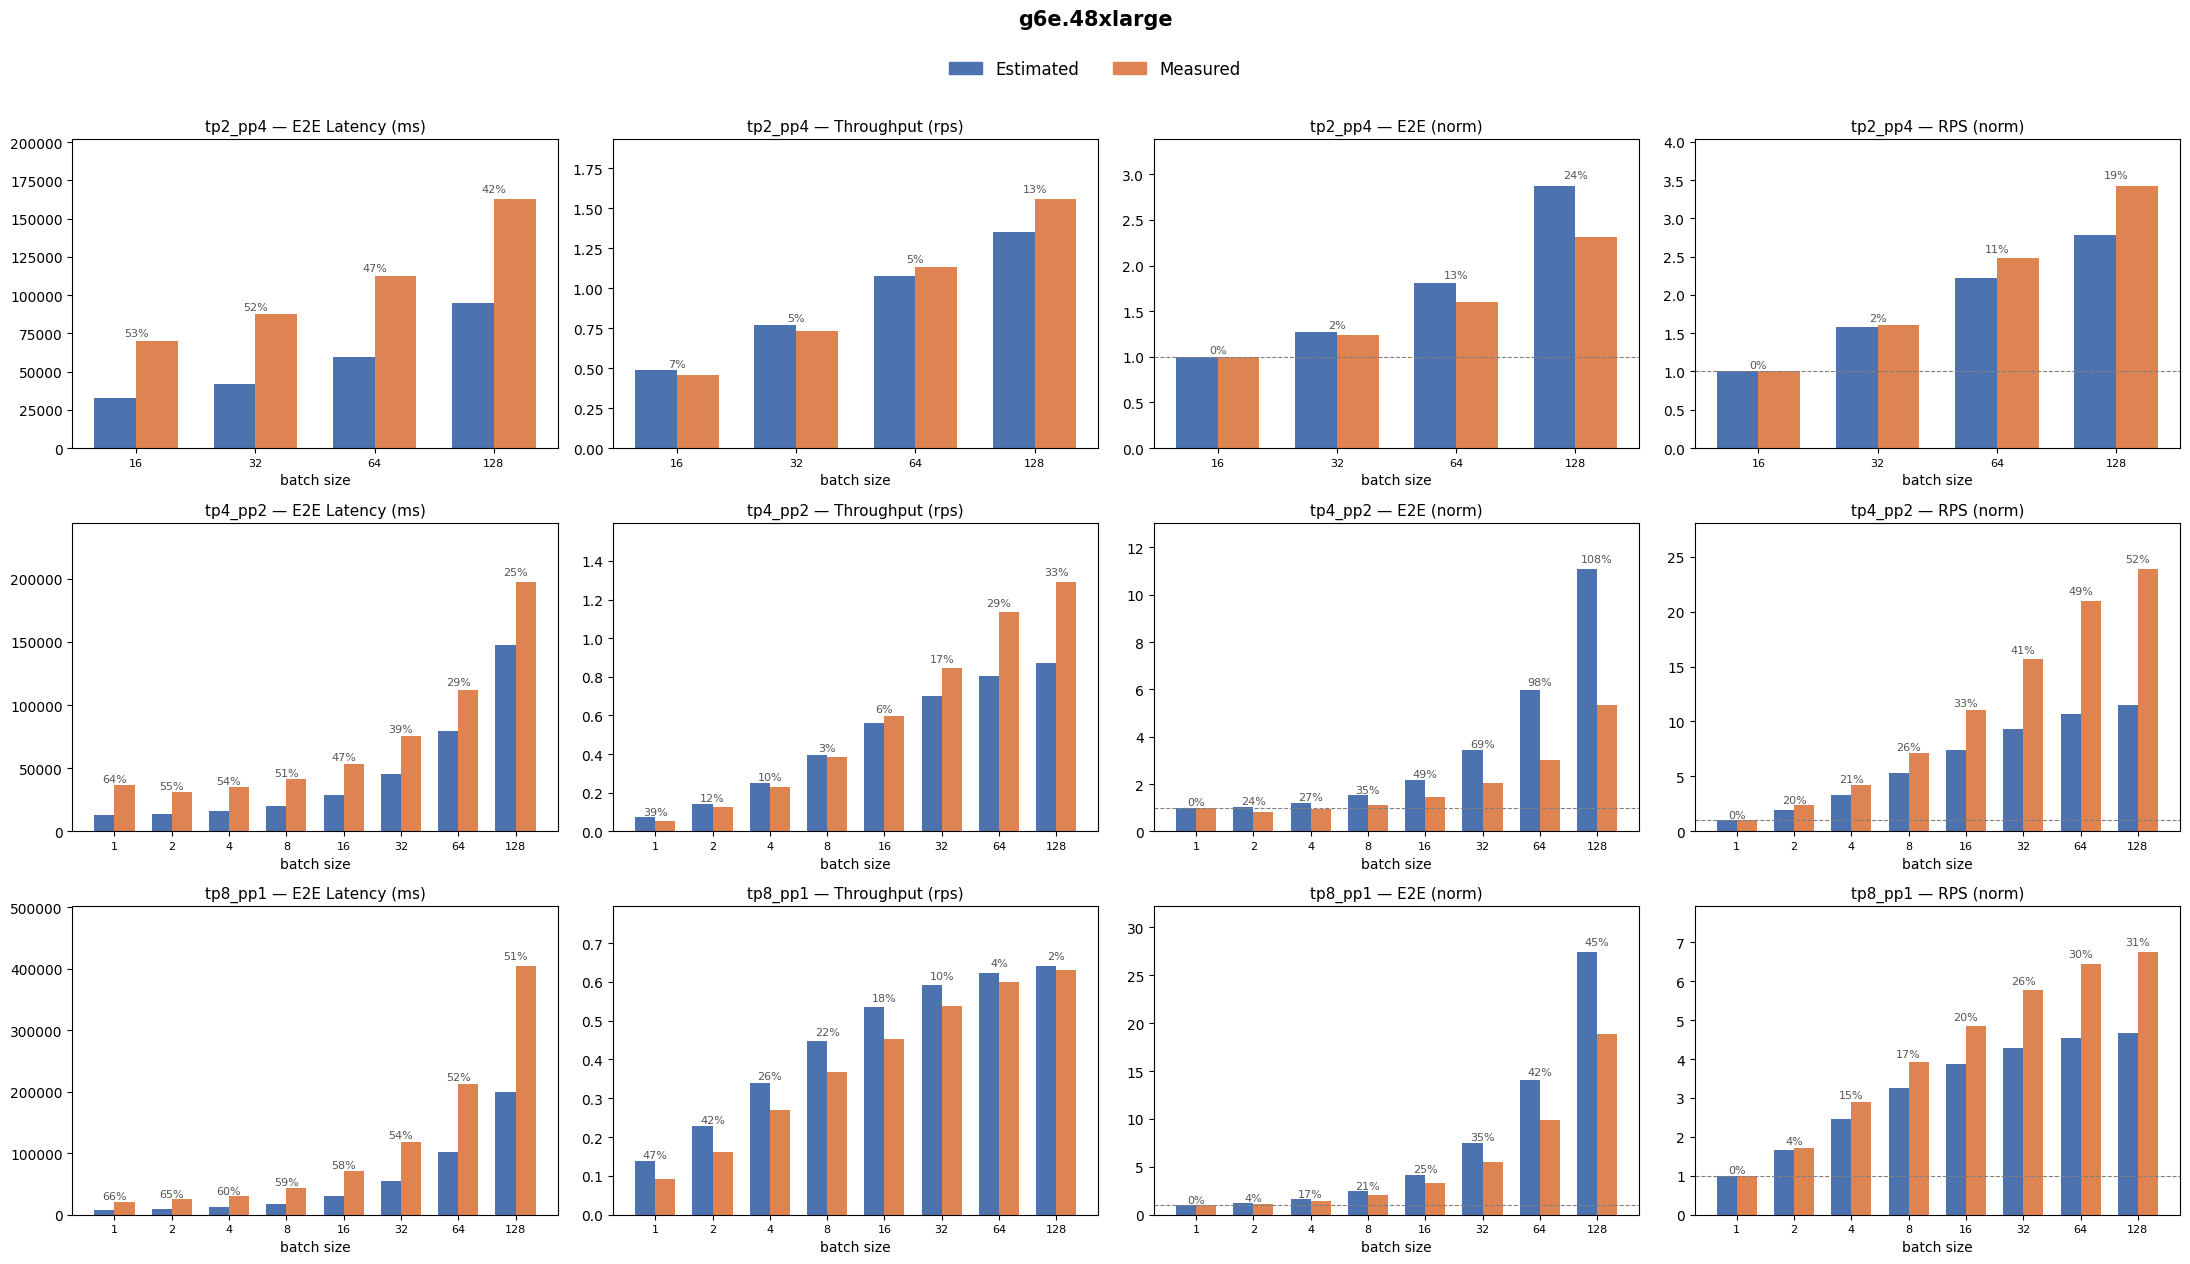

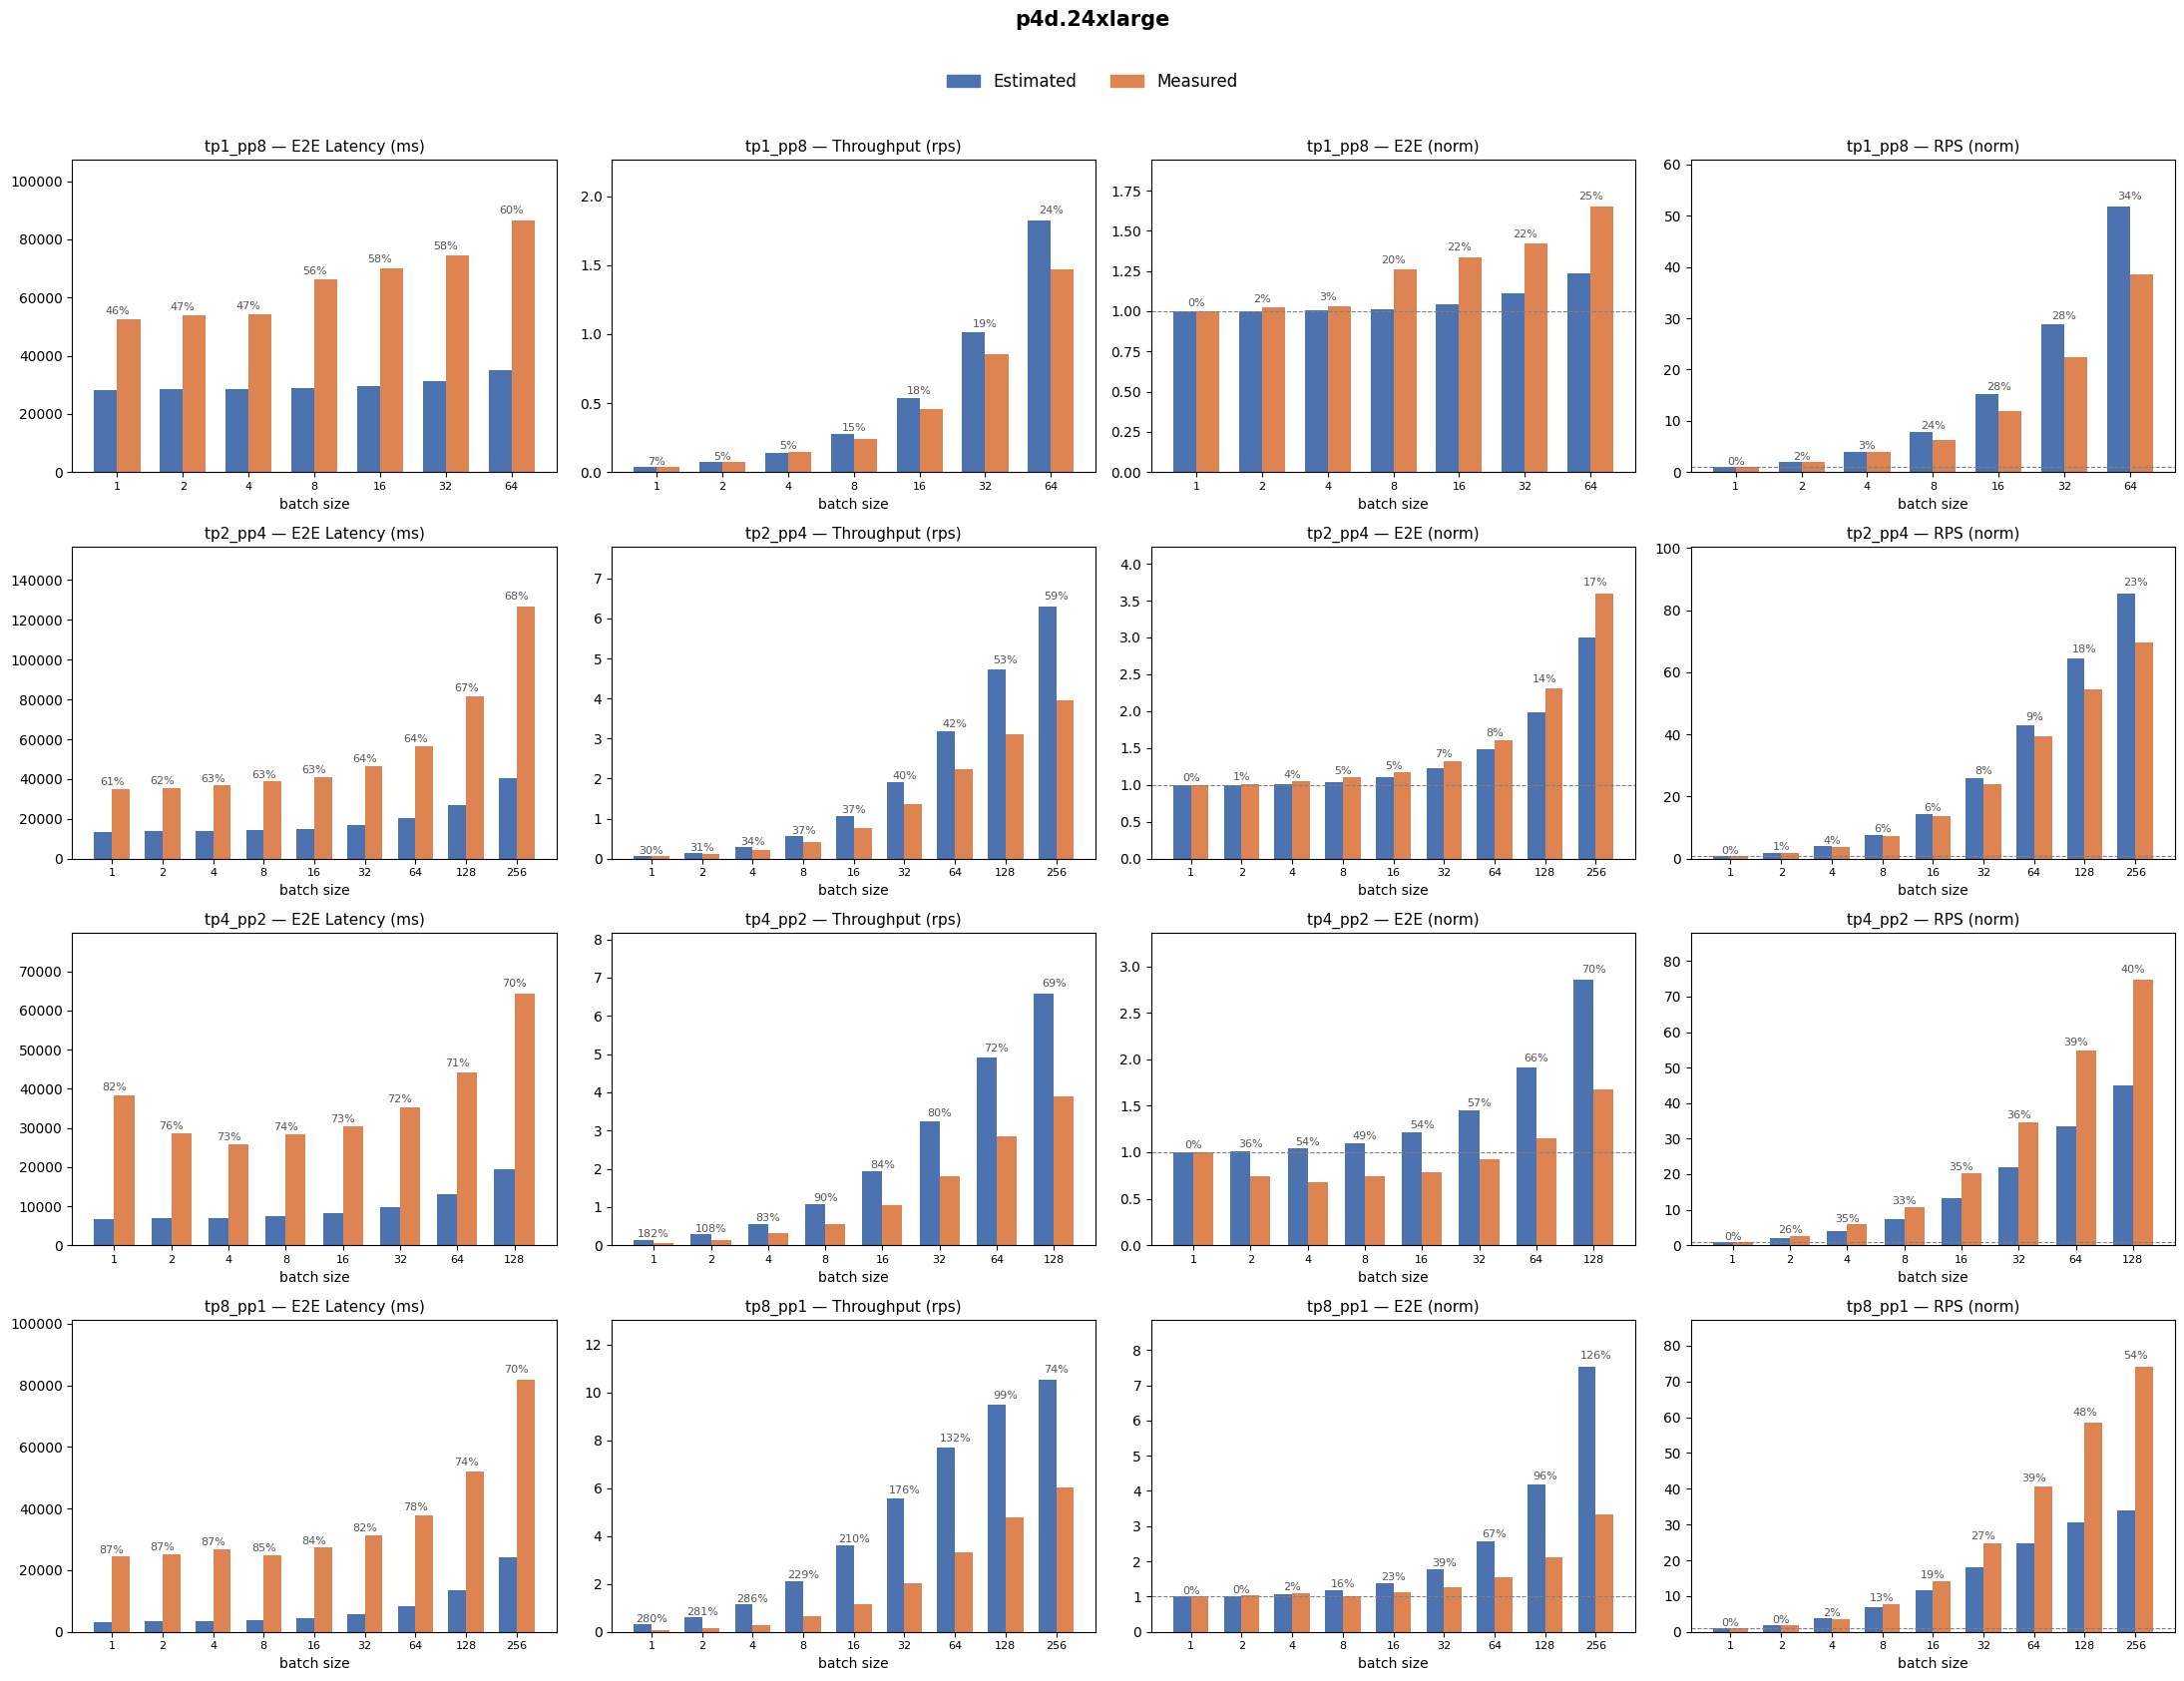

In [9]:
import matplotlib.pyplot as plt
import numpy as np

PLOT_COLS = ["e2e_ms", "rps"]
PLOT_LABELS = {"e2e_ms": "E2E Latency (ms)", "rps": "Throughput (rps)"}
NORM_LABELS = {"e2e_ms": "E2E (norm)", "rps": "RPS (norm)"}
C_EST, C_MEAS = "#4C72B0", "#DD8452"

if not meas_df.empty:
    instances = merged["instance"].unique()

    for inst in instances:
        inst_df = merged[merged["instance"] == inst]
        strat_groups = list(inst_df.groupby(["tp", "pp"]))
        n_strats = len(strat_groups)

        fig, axes = plt.subplots(n_strats, 4, figsize=(22, 4 * n_strats))
        if n_strats == 1:
            axes = [axes]

        # Shared legend at top
        from matplotlib.patches import Patch
        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"{inst}", fontsize=15, fontweight="bold", y=1.05)

        for row, ((tp, pp), grp) in enumerate(strat_groups):
            grp = grp.sort_values("batch")
            batches = grp["batch"].values
            x = np.arange(len(batches))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"tp{tp}_pp{pp} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels([str(b) for b in batches], fontsize=8)
                ax_raw.set_xlabel("batch size")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to batch=1
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"tp{tp}_pp{pp} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels([str(b) for b in batches], fontsize=8)
                ax_norm.set_xlabel("batch size")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()


---
## 6. Cross-GPU Comparison (Fixed TP/PP/Batch)

Compare estimated vs measured across GPU instance types at the same parallelism strategy and batch size.
X-axis = instance type, bars = estimated vs measured.

Instances with tp=8, pp=1: ['g5.48xlarge', 'g6.48xlarge', 'g6e.48xlarge', 'p4d.24xlarge']


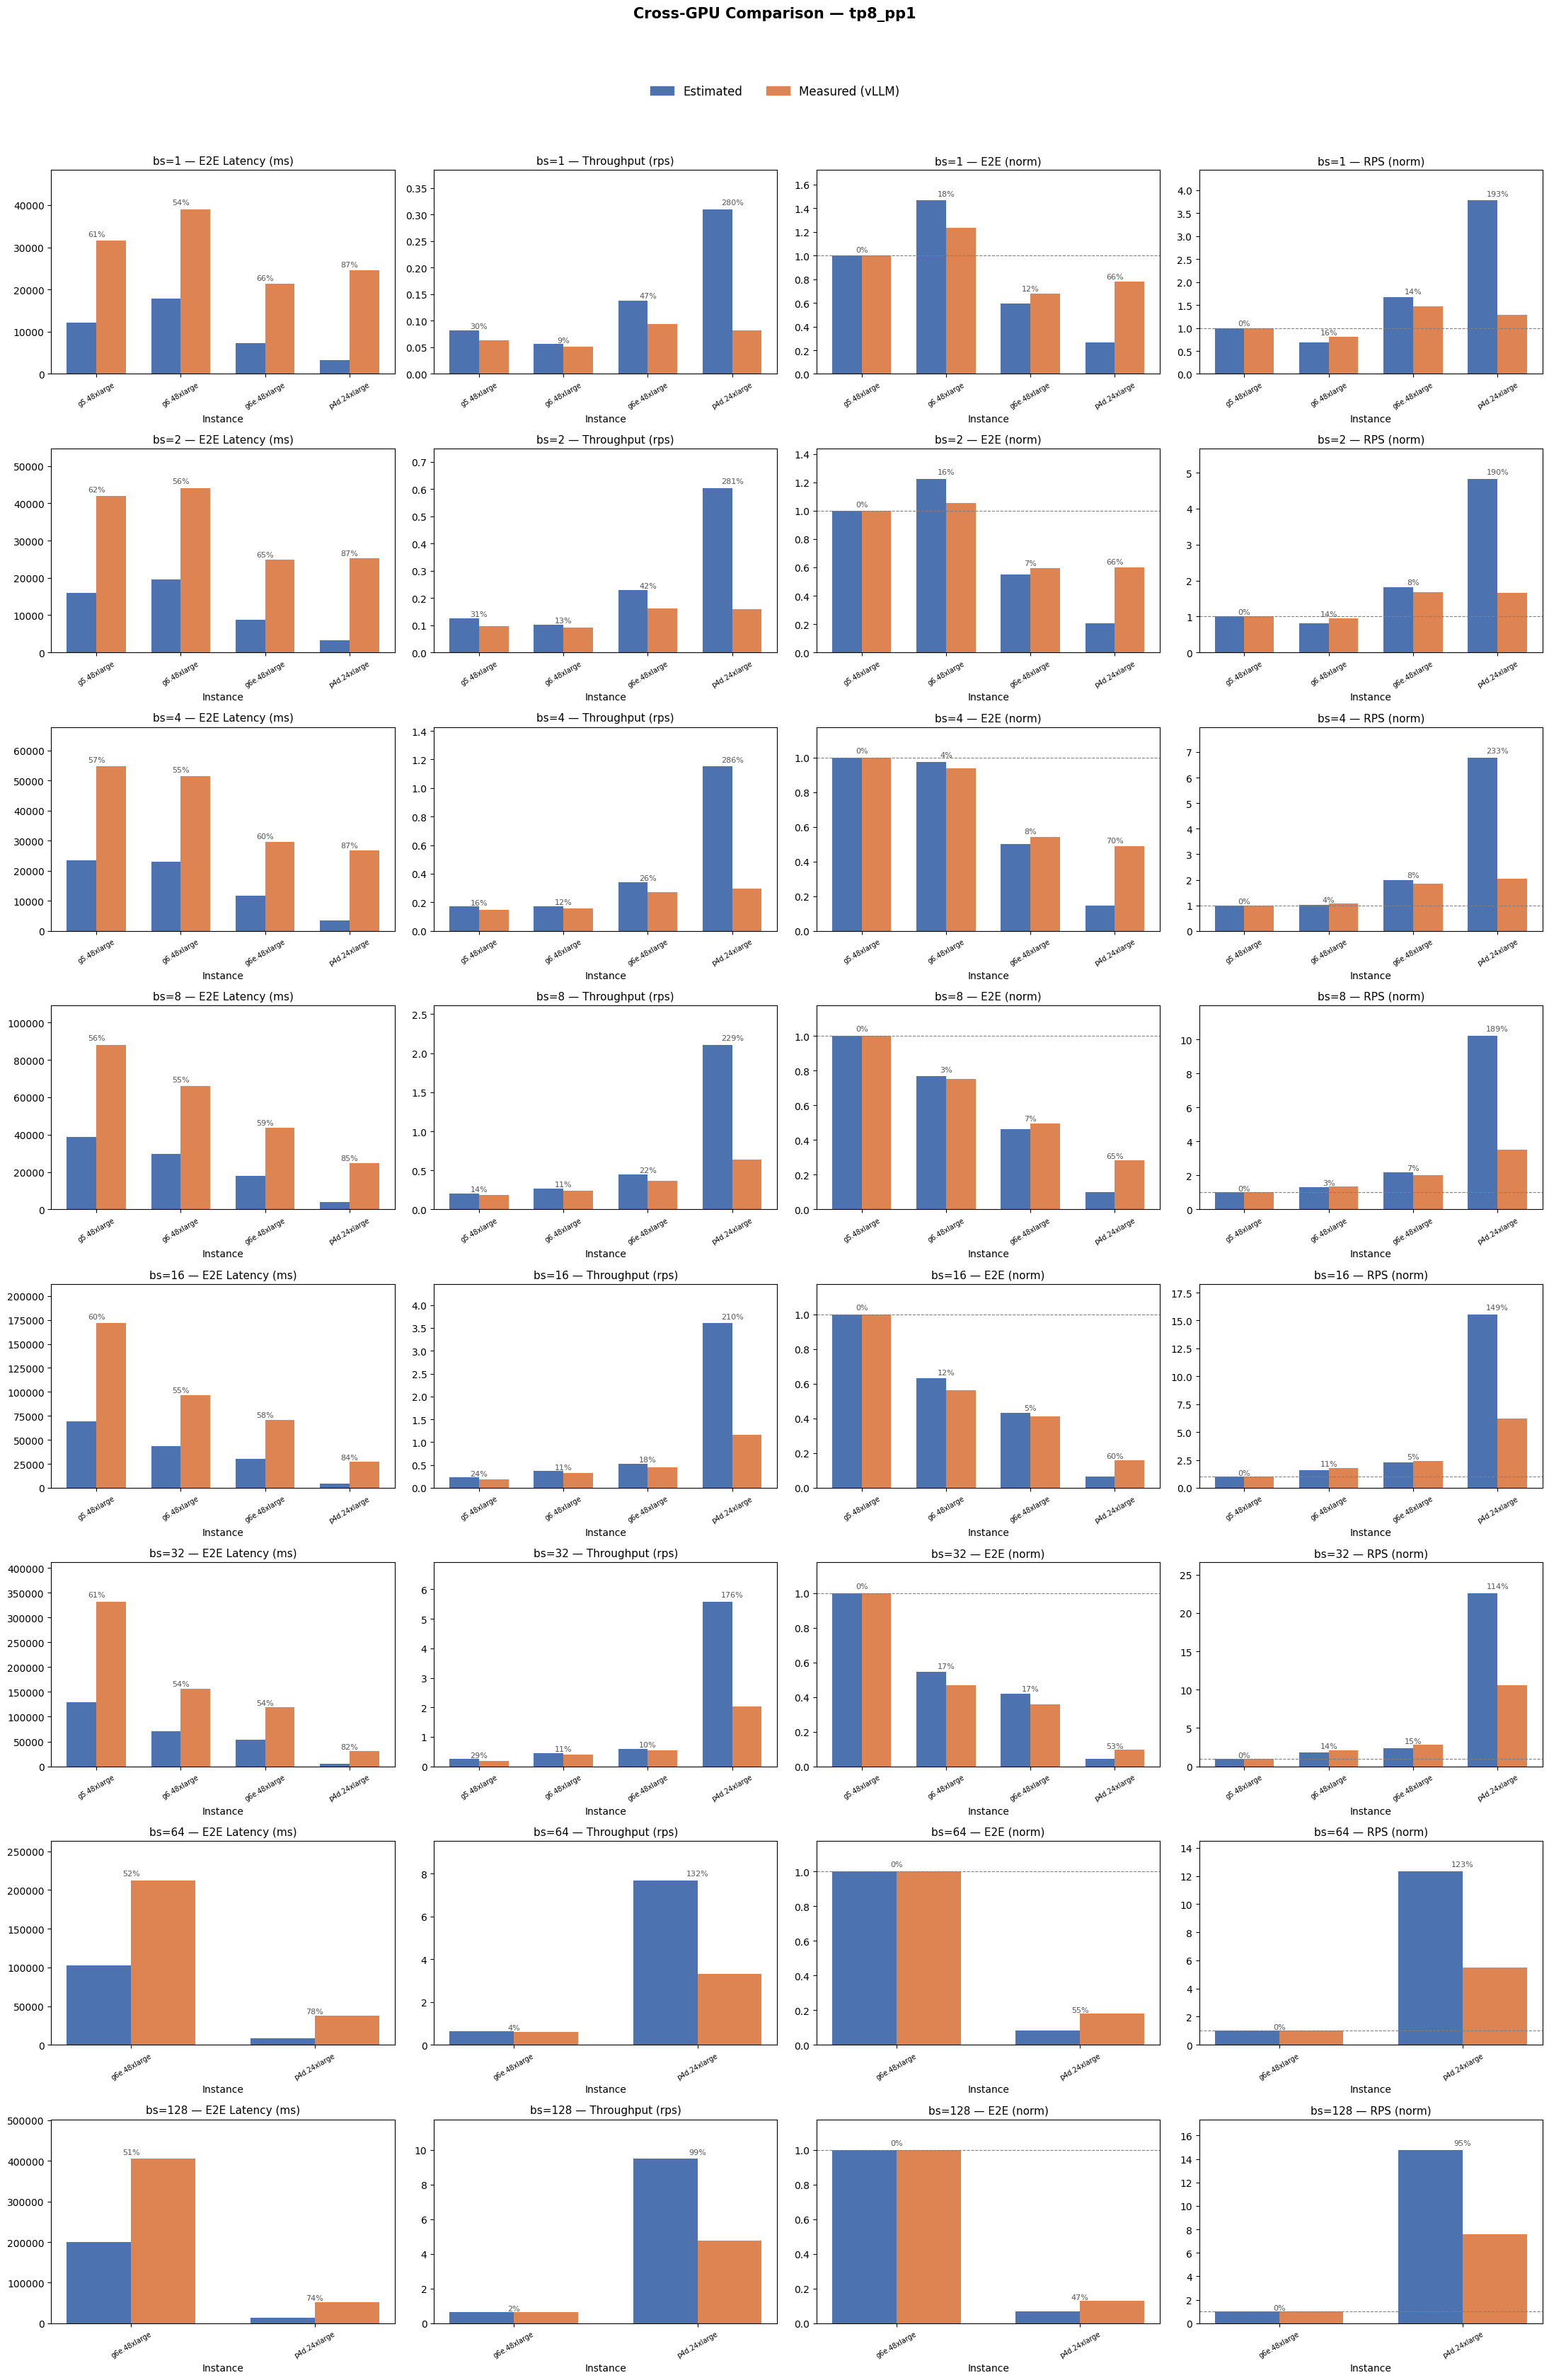

In [10]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 8
CROSS_PP = 1
CROSS_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not meas_df.empty:
    cross_merged = merged.copy()
    cross_merged = cross_merged[
        (cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)
    ]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    avail_instances = sorted(cross_merged["instance"].unique())
    print(f"Instances with tp={CROSS_TP}, pp={CROSS_PP}: {avail_instances}")

    if len(avail_instances) < 2:
        print(f"Need >= 2 instances for cross-GPU comparison, got {len(avail_instances)}")
    elif cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (vLLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()

Instances with tp=4, pp=2: ['g5.48xlarge', 'g6.48xlarge', 'g6e.48xlarge', 'p4d.24xlarge']


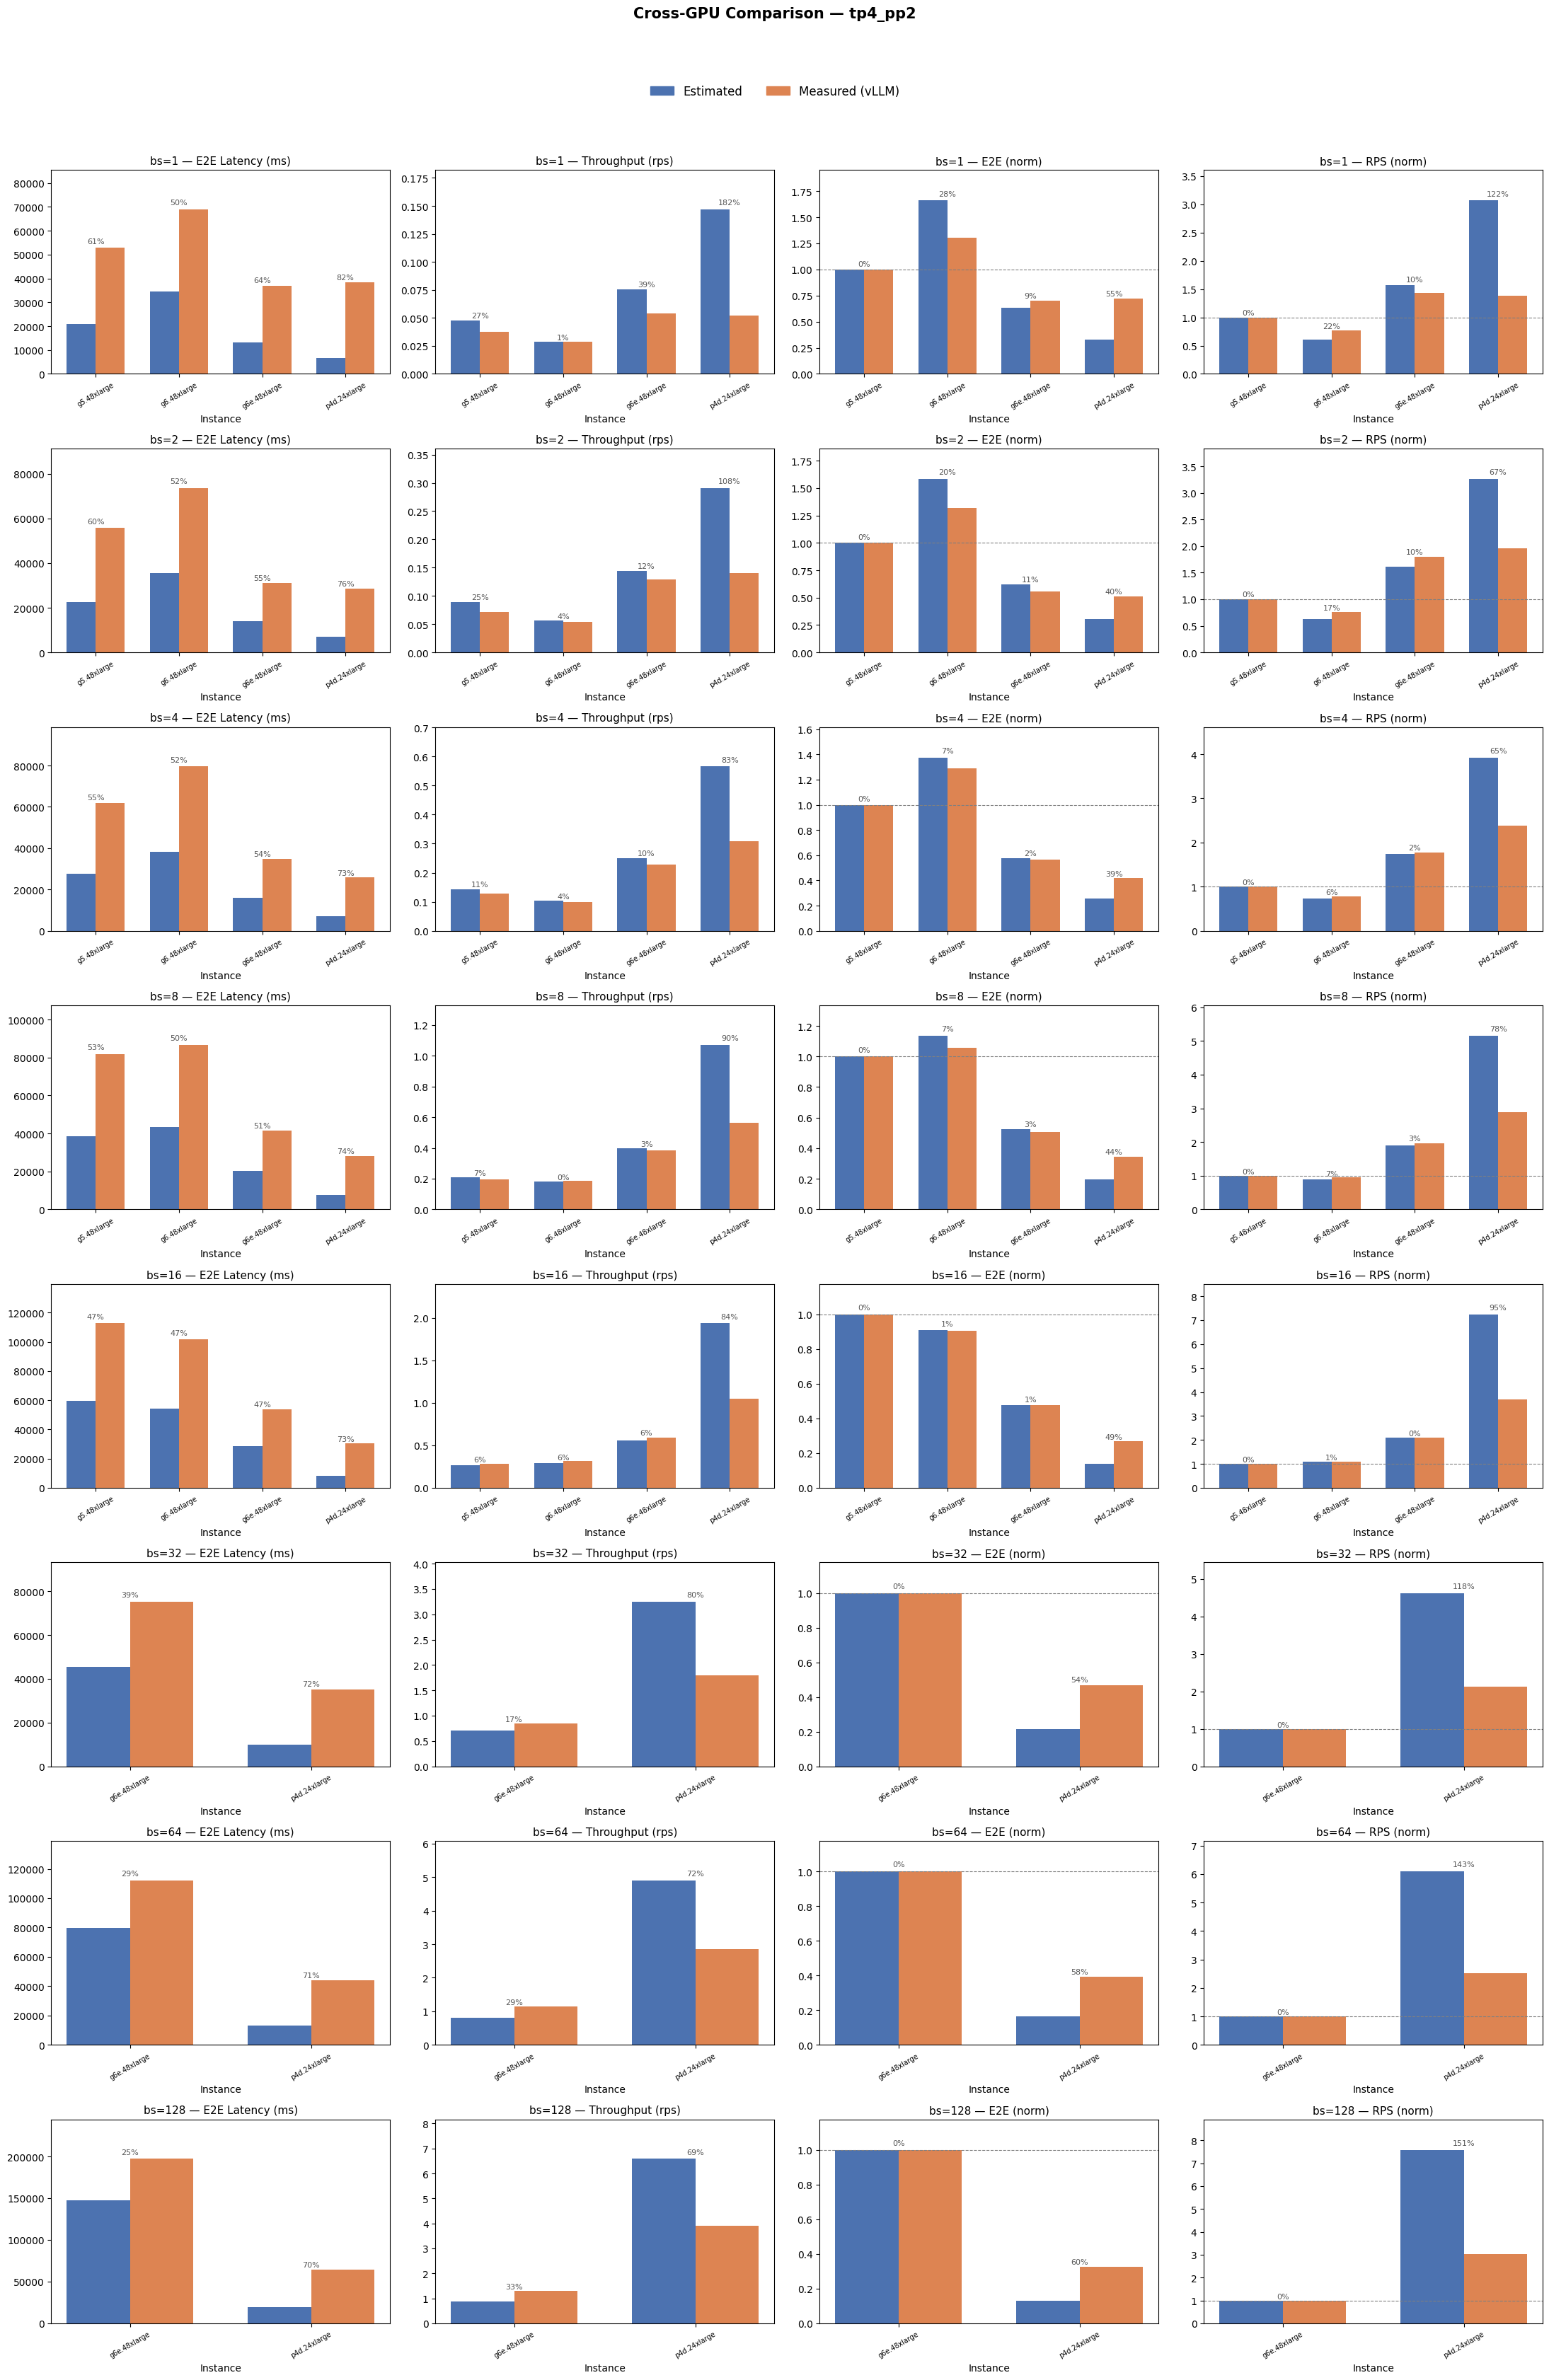

In [11]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 4
CROSS_PP = 2
CROSS_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not meas_df.empty:
    cross_merged = merged.copy()
    cross_merged = cross_merged[
        (cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)
    ]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    avail_instances = sorted(cross_merged["instance"].unique())
    print(f"Instances with tp={CROSS_TP}, pp={CROSS_PP}: {avail_instances}")

    if len(avail_instances) < 2:
        print(f"Need >= 2 instances for cross-GPU comparison, got {len(avail_instances)}")
    elif cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (vLLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()

Instances with tp=2, pp=4: ['g5.48xlarge', 'g6.48xlarge', 'g6e.48xlarge', 'p4d.24xlarge']


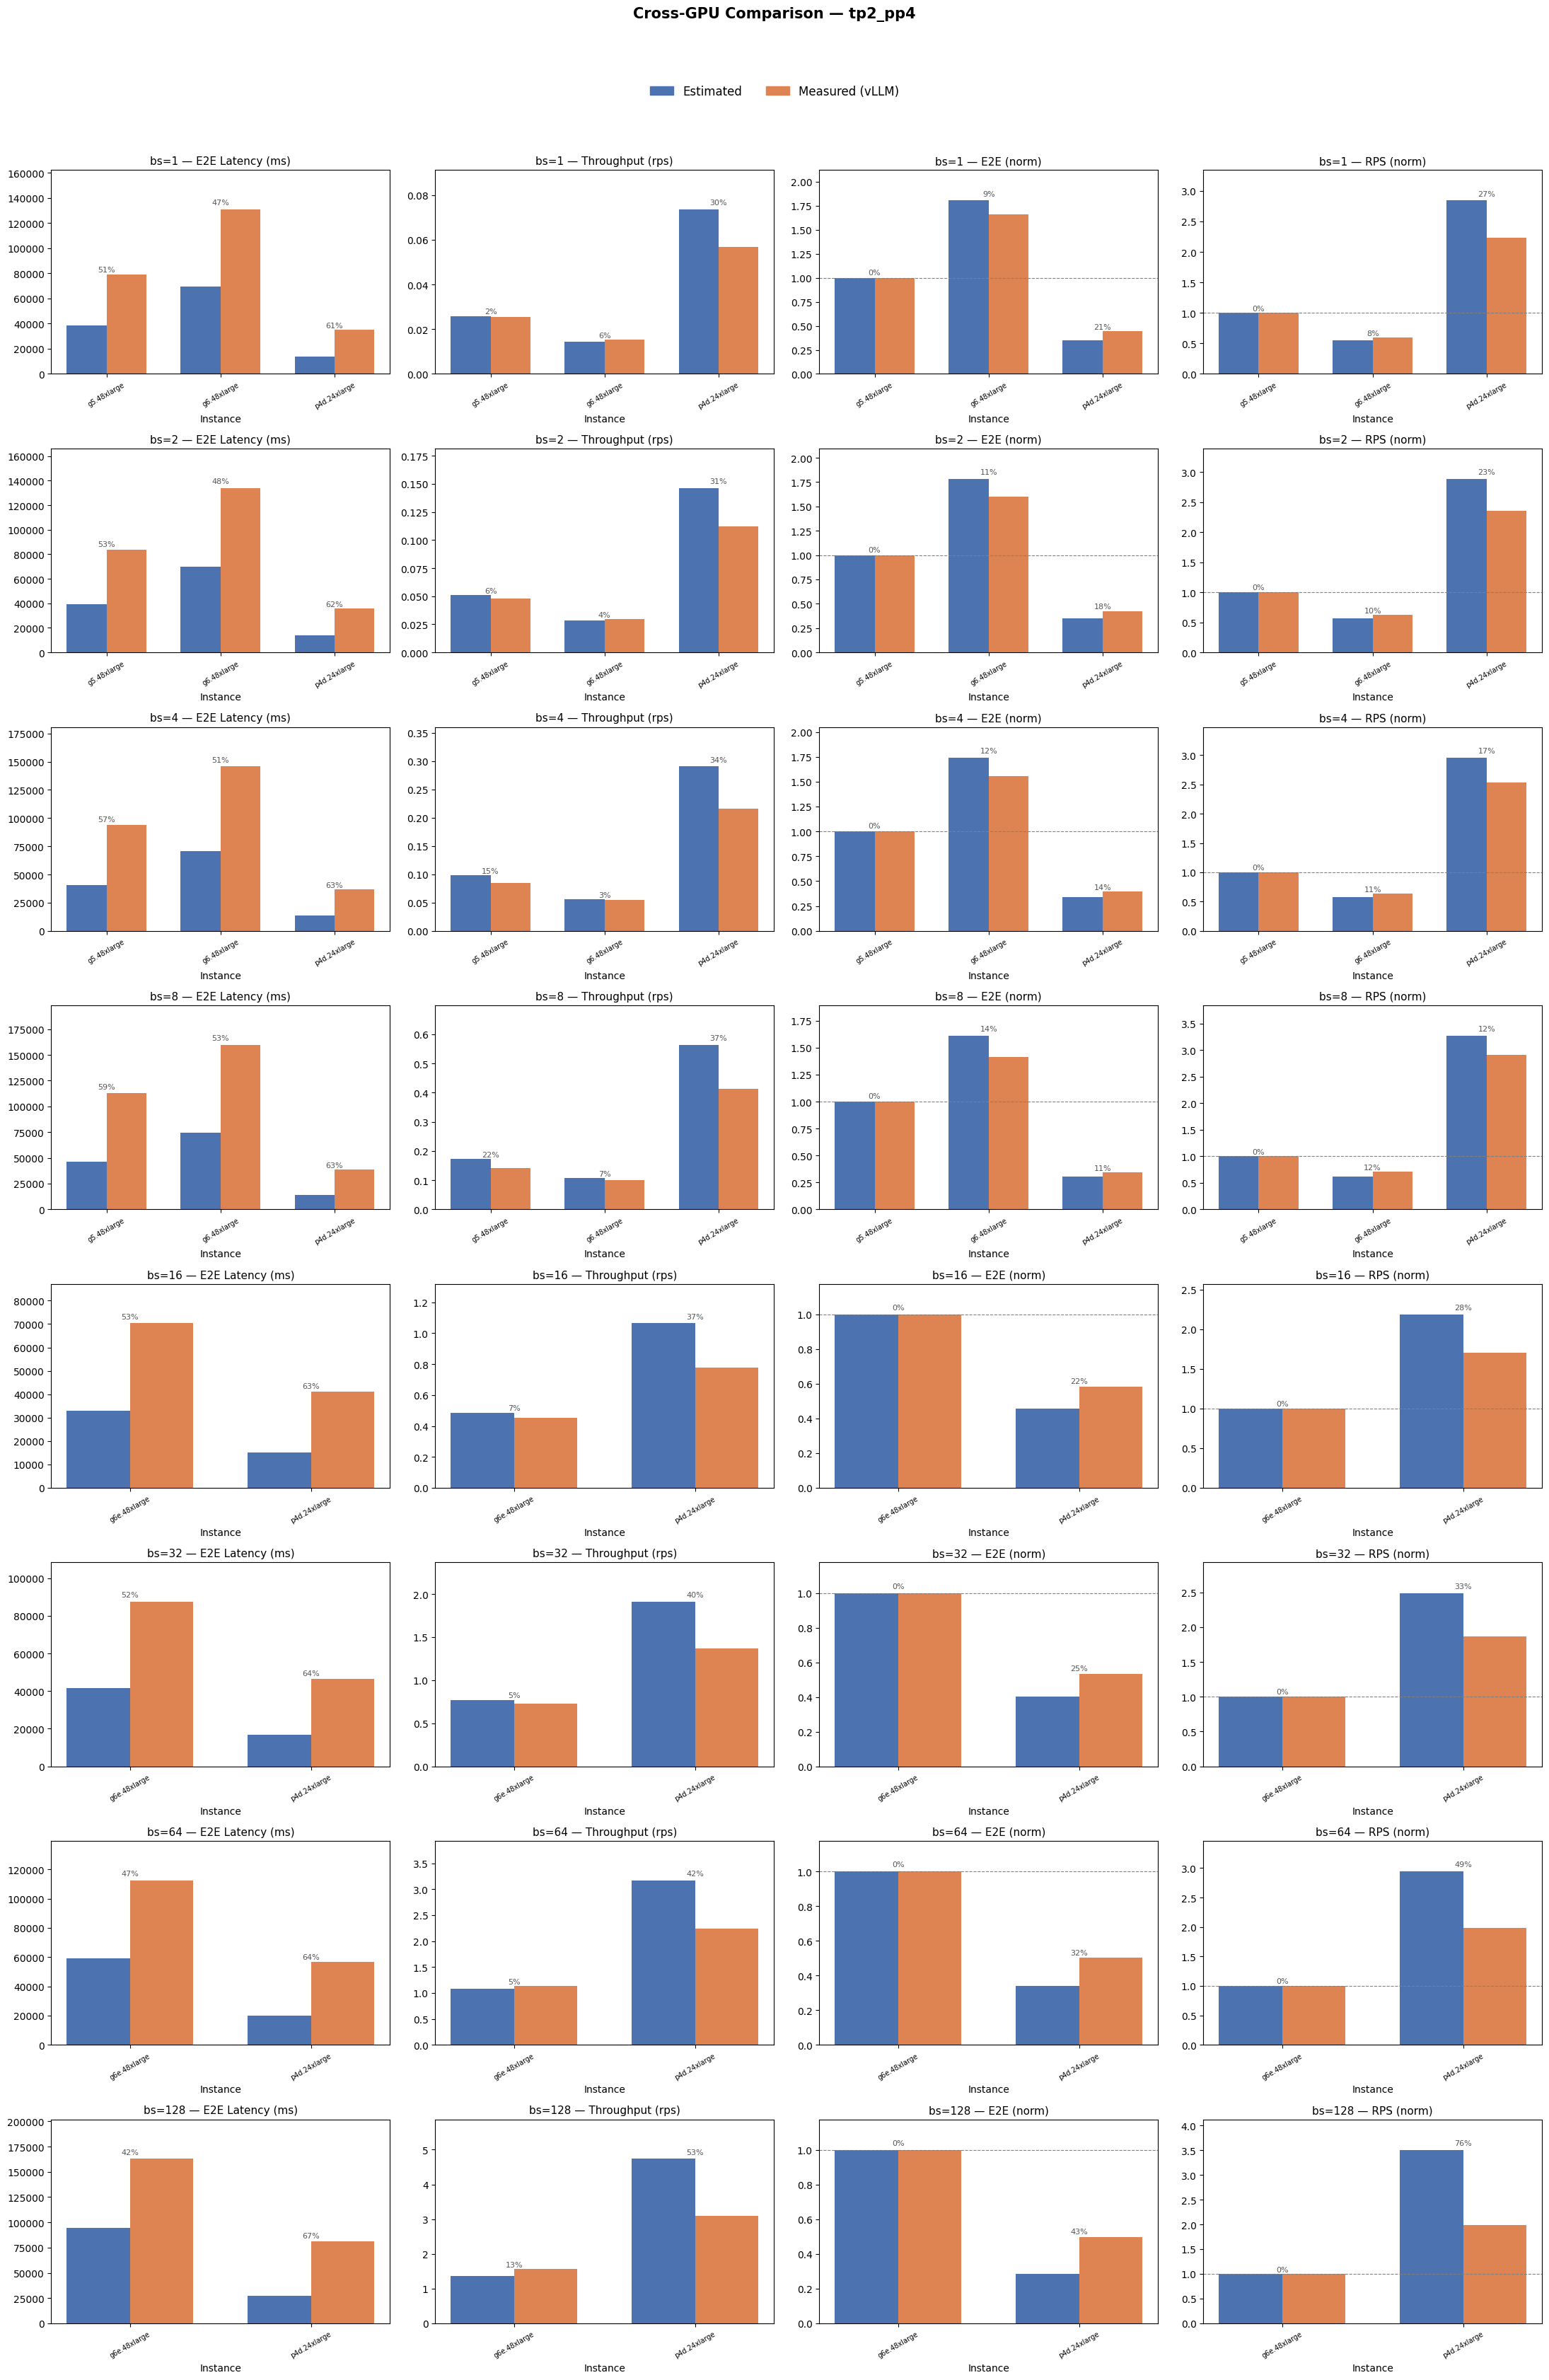

In [12]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 2
CROSS_PP = 4
CROSS_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not meas_df.empty:
    cross_merged = merged.copy()
    cross_merged = cross_merged[
        (cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)
    ]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    avail_instances = sorted(cross_merged["instance"].unique())
    print(f"Instances with tp={CROSS_TP}, pp={CROSS_PP}: {avail_instances}")

    if len(avail_instances) < 2:
        print(f"Need >= 2 instances for cross-GPU comparison, got {len(avail_instances)}")
    elif cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (vLLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()

In [13]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 1
CROSS_PP = 8
CROSS_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not meas_df.empty:
    cross_merged = merged.copy()
    cross_merged = cross_merged[
        (cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)
    ]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    avail_instances = sorted(cross_merged["instance"].unique())
    print(f"Instances with tp={CROSS_TP}, pp={CROSS_PP}: {avail_instances}")

    if len(avail_instances) < 2:
        print(f"Need >= 2 instances for cross-GPU comparison, got {len(avail_instances)}")
    elif cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (vLLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()

Instances with tp=1, pp=8: ['p4d.24xlarge']
Need >= 2 instances for cross-GPU comparison, got 1


---
## 4. Filter

In [14]:
filter_df(est_df, instance="g5.48xlarge", tp=2, pp=4)

,instance,tp,pp,batch,ttft_ms,tpot_ms,e2e_ms,rps
0,g5.48xlarge,2,4,1,2826.42,154.3356,38632.29,0.0259
1,g5.48xlarge,2,4,2,3533.03,77.1678,39338.89,0.0508
2,g5.48xlarge,2,4,4,4946.24,38.5839,40752.10,0.0982
3,g5.48xlarge,2,4,8,9892.49,19.6637,46388.24,0.1725
4,g5.48xlarge,2,4,11,13602.17,14.5036,50615.34,0.2173


In [15]:
filter_df(summary, instance="g6.48xlarge", tp=2, pp=4)

,instance,tp,pp,batch,ttft_ms_est,ttft_ms_meas,ttft_ms_mape%,tpot_ms_est,tpot_ms_meas,tpot_ms_mape%,e2e_ms_est,e2e_ms_meas,e2e_ms_mape%,rps_est,rps_meas,rps_mape%
0,g6.48xlarge,2,4,1,1831.22,1462.53,25.21,292.2931,560.6541,47.87,69643.21,130973.62,46.83,0.0144,0.0153,5.88
1,g6.48xlarge,2,4,2,2289.02,2521.80,9.23,146.1465,569.9779,74.36,70101.02,134186.70,47.76,0.0285,0.0298,4.36
2,g6.48xlarge,2,4,4,3204.63,2402.85,33.37,73.0733,621.1485,88.24,71016.63,145888.14,51.32,0.0563,0.0548,2.74
3,g6.48xlarge,2,4,8,6409.26,4757.32,34.72,36.7464,671.1135,94.52,74610.59,159784.54,53.31,0.1072,0.1001,7.09


In [16]:
filter_df(summary, instance="g6.48xlarge")

,instance,tp,pp,batch,ttft_ms_est,ttft_ms_meas,ttft_ms_mape%,tpot_ms_est,tpot_ms_meas,tpot_ms_mape%,e2e_ms_est,e2e_ms_meas,e2e_ms_mape%,rps_est,rps_meas,rps_mape%
0,g6.48xlarge,2,4,1,1831.22,1462.53,25.21,292.2931,560.6541,47.87,69643.21,130973.62,46.83,0.0144,0.0153,5.88
1,g6.48xlarge,2,4,2,2289.02,2521.80,9.23,146.1465,569.9779,74.36,70101.02,134186.70,47.76,0.0285,0.0298,4.36
2,g6.48xlarge,2,4,4,3204.63,2402.85,33.37,73.0733,621.1485,88.24,71016.63,145888.14,51.32,0.0563,0.0548,2.74
3,g6.48xlarge,2,4,8,6409.26,4757.32,34.72,36.7464,671.1135,94.52,74610.59,159784.54,53.31,0.1072,0.1001,7.09
4,g6.48xlarge,4,2,1,1542.71,1052.98,46.51,142.7901,293.9695,51.43,34670.01,68959.94,49.72,0.0288,0.0290,0.69
5,g6.48xlarge,4,2,2,2314.07,1867.37,23.92,71.3950,311.0278,77.05,35441.37,73714.78,51.92,0.0564,0.0542,4.06
6,g6.48xlarge,4,2,4,4628.14,2207.49,109.66,36.1189,335.1103,89.22,38146.43,79617.98,52.09,0.1049,0.1004,4.48
7,g6.48xlarge,4,2,8,9256.28,4101.07,125.70,18.4808,357.6108,94.83,43556.56,86709.17,49.77,0.1837,0.1844,0.38
8,g6.48xlarge,4,2,16,18512.57,8148.55,127.19,9.6617,405.5404,97.62,54376.82,101828.39,46.60,0.2942,0.3139,6.28
9,g6.48xlarge,8,1,1,1342.45,1304.68,2.89,71.1029,163.1168,56.41,17838.32,38984.66,54.24,0.0561,0.0513,9.36
